<a href="https://colab.research.google.com/github/EktaSinghES/Machine_Learning_Lab-2547221/blob/LAB10/Lab_Exercise_10_XOR_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

## Aim

1. Understand neural-network implementation using **Keras** and the **TensorFlow low-level API**.
2. Solve the non-linearly separable XOR problem using a multilayer perceptron (MLP).
3. Study how learning rate, activation function, hidden neurons, and epochs affect performance.

## Self Learning

Before training the required MLP, we manually build perceptrons for AND, OR, and NOT. This makes the limitation of a single perceptron visible: it learns linearly separable gates, but cannot represent XOR. We then add a hidden layer and solve XOR in three ways:

1. A manual NumPy MLP with backpropagation (conceptual bridge)
2. Keras (`tf.keras`) high-level API
3. TensorFlow low-level API using variables and `GradientTape`



## Experiment plan and requirement checklist

| Assignment requirement | Where it is covered |
|---|---|
| Create all four XOR samples | Dataset section |
| 2-input MLP, hidden layer, sigmoid output | All three MLP implementations |
| Binary cross-entropy | NumPy, Keras, and low-level TensorFlow |
| Adam or SGD optimizer | Keras and TensorFlow use Adam; NumPy uses gradient descent |
| Train and predict all four combinations | Evaluation section |
| Experiment with epochs, learning rate, activation, neurons | Hyperparameter experiments |
| Plot decision boundaries | Perceptron and MLP visualization sections |
| Compare training curves and accuracy | Comparison section |
| Discuss hyperparameter effects | Observations and conclusion |

**Expected XOR truth table:**

| Input 1 | Input 2 | XOR output |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

In [1]:
# Run this cell only if the required packages are missing:
# %pip install -q numpy pandas matplotlib tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import tensorflow as tf

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

COLORS = ["#4C78A8", "#F58518"]
CMAP = ListedColormap(["#B9D7EA", "#FFD3A5"])
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Create the XOR dataset

Each row is one possible pair of binary inputs. Keeping `y` as a column vector makes its shape compatible with a one-neuron output layer.

,Input 1,Input 2,XOR Output
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


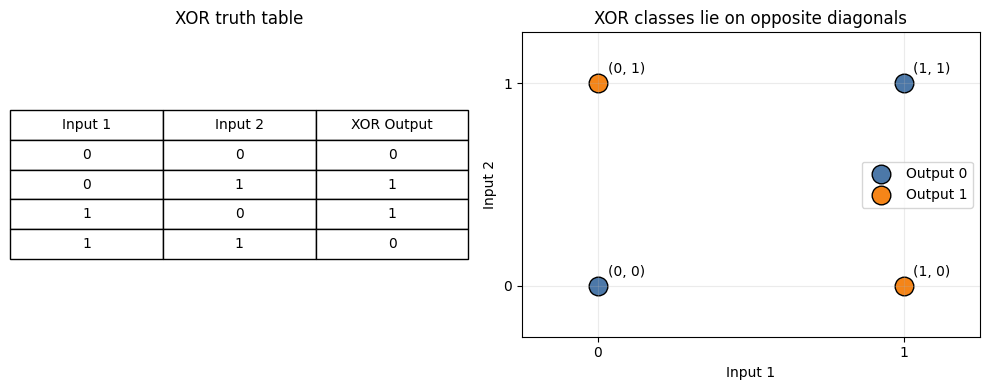

In [2]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

xor_table = pd.DataFrame({
    "Input 1": X[:, 0].astype(int),
    "Input 2": X[:, 1].astype(int),
    "XOR Output": y.ravel().astype(int)
})
display(xor_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].axis("off")
table = axes[0].table(cellText=xor_table.values,
                      colLabels=xor_table.columns,
                      loc="center", cellLoc="center")
table.scale(1, 1.8)
axes[0].set_title("XOR truth table")

for cls, label in [(0, "Output 0"), (1, "Output 1")]:
    mask = y.ravel() == cls
    axes[1].scatter(X[mask, 0], X[mask, 1], s=180,
                    color=COLORS[cls], edgecolor="black", label=label)
for i, (x1, x2) in enumerate(X):
    axes[1].annotate(f"({int(x1)}, {int(x2)})", (x1, x2),
                     xytext=(7, 7), textcoords="offset points")
axes[1].set(xlim=(-0.25, 1.25), ylim=(-0.25, 1.25),
            xticks=[0, 1], yticks=[0, 1], xlabel="Input 1", ylabel="Input 2",
            title="XOR classes lie on opposite diagonals")
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Manual perceptrons: AND, OR, and NOT

A perceptron computes

$$\hat y = \operatorname{step}(w^T x + b).$$

The weights define a straight decision boundary. Carefully chosen weights are sufficient for AND, OR, and NOT because those gates are linearly separable.

In [3]:
def step(z):
    return (np.asarray(z) >= 0).astype(int)

def perceptron_predict(inputs, weights, bias):
    inputs = np.asarray(inputs, dtype=float)
    return step(inputs @ np.asarray(weights, dtype=float) + bias)

gate_parameters = {
    "AND": (np.array([1.0, 1.0]), -1.5),
    "OR":  (np.array([1.0, 1.0]), -0.5),
}

results = xor_table[["Input 1", "Input 2"]].copy()
for gate, (weights, bias) in gate_parameters.items():
    results[gate] = perceptron_predict(X, weights, bias)

not_inputs = np.array([[0], [1]], dtype=float)
not_outputs = perceptron_predict(not_inputs, weights=[-1.0], bias=0.5)

display(results)
display(pd.DataFrame({"Input": not_inputs.ravel().astype(int),
                      "NOT": not_outputs.ravel()}))

assert results["AND"].tolist() == [0, 0, 0, 1]
assert results["OR"].tolist() == [0, 1, 1, 1]
assert not_outputs.ravel().tolist() == [1, 0]
print("The manually selected perceptrons implement AND, OR, and NOT correctly.")

,Input 1,Input 2,AND,OR
0,0,0,0,0
1,0,1,0,1
2,1,0,0,1
3,1,1,1,1


,Input,NOT
0,0,1
1,1,0


The manually selected perceptrons implement AND, OR, and NOT correctly.


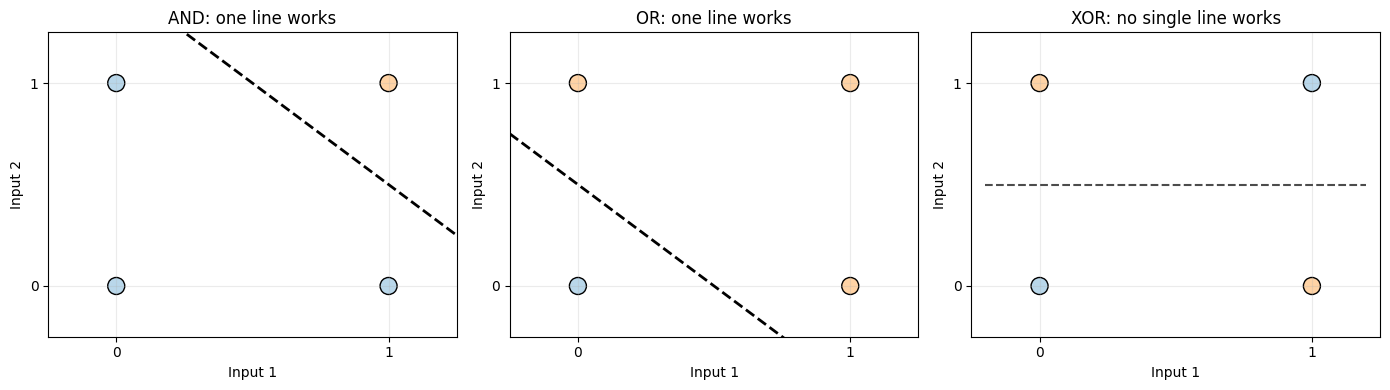

In [4]:
def plot_gate_boundary(ax, weights, bias, targets, title):
    x_line = np.linspace(-0.25, 1.25, 200)
    ax.scatter(X[:, 0], X[:, 1], c=np.asarray(targets).ravel(),
               cmap=CMAP, s=150, edgecolor="black")
    if abs(weights[1]) > 1e-12:
        y_line = -(weights[0] * x_line + bias) / weights[1]
        ax.plot(x_line, y_line, "k--", lw=2, label="decision boundary")
    ax.set(xlim=(-0.25, 1.25), ylim=(-0.25, 1.25), xticks=[0, 1], yticks=[0, 1],
           xlabel="Input 1", ylabel="Input 2", title=title)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_gate_boundary(axes[0], *gate_parameters["AND"], [0, 0, 0, 1], "AND: one line works")
plot_gate_boundary(axes[1], *gate_parameters["OR"], [0, 1, 1, 1], "OR: one line works")
axes[2].scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=CMAP, s=150, edgecolor="black")
axes[2].plot([-0.2, 1.2], [0.5, 0.5], "k--", alpha=0.7, label="example line")
axes[2].set(xlim=(-0.25, 1.25), ylim=(-0.25, 1.25), xticks=[0, 1], yticks=[0, 1],
            xlabel="Input 1", ylabel="Input 2", title="XOR: no single line works")
axes[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Let a perceptron learn—and observe XOR failure

The perceptron learning rule updates its weights when a sample is misclassified:

$$w \leftarrow w + \eta(y-\hat y)x, \qquad b \leftarrow b + \eta(y-\hat y).$$

It should reach zero errors for AND and OR. For XOR it keeps making corrections because fixing one diagonal point tends to break another. This is a representational limitation, not simply a shortage of epochs.

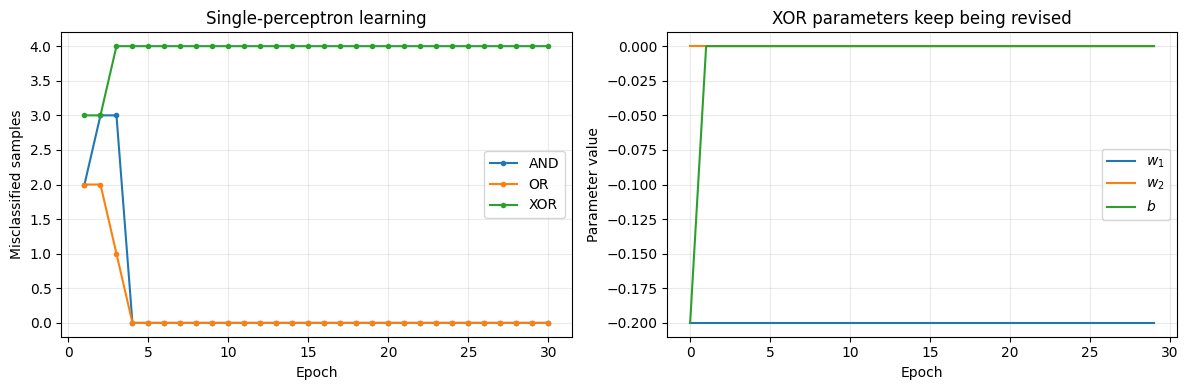

,Gate,Final weights,Final bias,Predictions,Accuracy
0,AND,"[0.4, 0.2]",-0.4,"[0, 0, 0, 1]",1.0
1,OR,"[0.2, 0.2]",-0.2,"[0, 1, 1, 1]",1.0
2,XOR,"[-0.2, 0.0]",0.0,"[1, 1, 0, 0]",0.5


In [5]:
def train_perceptron(X_data, y_data, learning_rate=0.2, epochs=30):
    weights = np.zeros(X_data.shape[1], dtype=float)
    bias = 0.0
    errors_per_epoch = []
    weight_history = []
    for _ in range(epochs):
        errors = 0
        for xi, target in zip(X_data, np.asarray(y_data).ravel().astype(int)):
            prediction = int(step(xi @ weights + bias))
            update = learning_rate * (target - prediction)
            weights += update * xi
            bias += update
            errors += int(update != 0)
        errors_per_epoch.append(errors)
        weight_history.append(np.r_[weights, bias].copy())
    return weights, bias, np.array(errors_per_epoch), np.array(weight_history)

gate_targets = {
    "AND": np.array([0, 0, 0, 1]),
    "OR":  np.array([0, 1, 1, 1]),
    "XOR": y.ravel().astype(int),
}
learned_perceptrons = {
    name: train_perceptron(X, targets, epochs=30)
    for name, targets in gate_targets.items()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (_, _, errors, history) in learned_perceptrons.items():
    axes[0].plot(range(1, len(errors) + 1), errors, marker="o", ms=3, label=name)
    if name == "XOR":
        axes[1].plot(history[:, 0], label="$w_1$")
        axes[1].plot(history[:, 1], label="$w_2$")
        axes[1].plot(history[:, 2], label="$b$")
axes[0].set(xlabel="Epoch", ylabel="Misclassified samples",
            title="Single-perceptron learning", ylim=(-0.2, 4.2))
axes[0].grid(alpha=0.25); axes[0].legend()
axes[1].set(xlabel="Epoch", ylabel="Parameter value",
            title="XOR parameters keep being revised")
axes[1].grid(alpha=0.25); axes[1].legend()
plt.tight_layout()
plt.show()

summary_rows = []
for name, (weights, bias, errors, _) in learned_perceptrons.items():
    predictions = perceptron_predict(X, weights, bias)
    summary_rows.append([name, weights, bias, predictions,
                         np.mean(predictions == gate_targets[name])])
display(pd.DataFrame(summary_rows,
                     columns=["Gate", "Final weights", "Final bias", "Predictions", "Accuracy"]))

### Why the single perceptron cannot learn XOR

The XOR positive samples are $(0,1)$ and $(1,0)$, while the negative samples are $(0,0)$ and $(1,1)$. No straight line can place both positive points on one side and both negative points on the other. A hidden layer solves this by creating multiple intermediate boundaries; the output neuron combines them into a non-linear region.

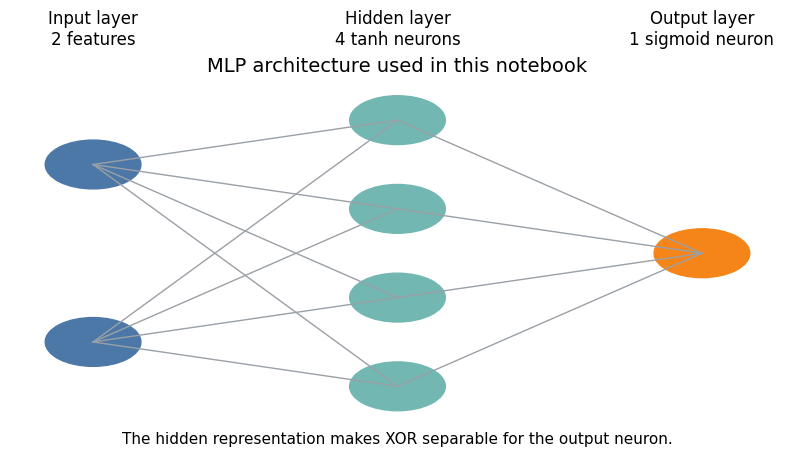

In [6]:
# Visualize the requested 2 -> hidden -> 1 architecture.
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")
input_pos = [(0.15, 0.65), (0.15, 0.25)]
hidden_pos = [(0.50, y0) for y0 in np.linspace(0.15, 0.75, 4)]
output_pos = [(0.85, 0.45)]
for start in input_pos:
    for end in hidden_pos:
        ax.plot([start[0], end[0]], [start[1], end[1]], color="#9AA0A6", lw=1)
for start in hidden_pos:
    ax.plot([start[0], output_pos[0][0]], [start[1], output_pos[0][1]], color="#9AA0A6", lw=1)
for x0, y0 in input_pos:
    ax.add_patch(plt.Circle((x0, y0), 0.055, color="#4C78A8"))
for x0, y0 in hidden_pos:
    ax.add_patch(plt.Circle((x0, y0), 0.055, color="#72B7B2"))
for x0, y0 in output_pos:
    ax.add_patch(plt.Circle((x0, y0), 0.055, color="#F58518"))
ax.text(0.15, 0.92, "Input layer\n2 features", ha="center", fontsize=12)
ax.text(0.50, 0.92, "Hidden layer\n4 tanh neurons", ha="center", fontsize=12)
ax.text(0.85, 0.92, "Output layer\n1 sigmoid neuron", ha="center", fontsize=12)
ax.text(0.5, 0.02, "The hidden representation makes XOR separable for the output neuron.",
        ha="center", fontsize=11)
ax.set_title("MLP architecture used in this notebook", fontsize=14)
plt.show()

## 4. Implementation A — manual NumPy MLP

This network has two inputs, four tanh hidden neurons, and one sigmoid output neuron. Binary cross-entropy is minimized using manually written forward propagation, backpropagation, and gradient-descent updates.

Binary cross-entropy:

$$L=-\frac{1}{m}\sum_{i=1}^m\left[y_i\log(\hat y_i)+(1-y_i)\log(1-\hat y_i)\right].$$

In [7]:
def sigmoid_np(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

def predict_numpy_mlp(X_data, params):
    hidden = np.tanh(X_data @ params["W1"] + params["b1"])
    return sigmoid_np(hidden @ params["W2"] + params["b2"])

def train_numpy_mlp(X_data, y_data, hidden_neurons=4,
                    learning_rate=0.1, epochs=10000, seed=42):
    rng = np.random.default_rng(seed)
    m, n_inputs = X_data.shape
    params = {
        "W1": rng.normal(0, 0.8, (n_inputs, hidden_neurons)),
        "b1": np.zeros((1, hidden_neurons)),
        "W2": rng.normal(0, 0.8, (hidden_neurons, 1)),
        "b2": np.zeros((1, 1)),
    }
    loss_history = []

    for _ in range(epochs):
        z1 = X_data @ params["W1"] + params["b1"]
        a1 = np.tanh(z1)
        predictions = sigmoid_np(a1 @ params["W2"] + params["b2"])

        eps = 1e-7
        loss = -np.mean(y_data * np.log(predictions + eps) +
                        (1 - y_data) * np.log(1 - predictions + eps))
        loss_history.append(loss)

        # For sigmoid + BCE, dL/dz2 simplifies to (prediction - target) / m.
        dz2 = (predictions - y_data) / m
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        dz1 = (dz2 @ params["W2"].T) * (1 - a1 ** 2)
        dW1 = X_data.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        params["W2"] -= learning_rate * dW2
        params["b2"] -= learning_rate * db2
        params["W1"] -= learning_rate * dW1
        params["b1"] -= learning_rate * db1

    return params, np.array(loss_history)

numpy_params, numpy_loss = train_numpy_mlp(X, y)
numpy_prob = predict_numpy_mlp(X, numpy_params)
numpy_pred = (numpy_prob >= 0.5).astype(int)

display(pd.DataFrame({"Input": [tuple(v.astype(int)) for v in X],
                      "Expected": y.ravel().astype(int),
                      "Probability": numpy_prob.ravel(),
                      "Predicted": numpy_pred.ravel()}))
print("NumPy MLP accuracy:", np.mean(numpy_pred == y))

,Input,Expected,Probability,Predicted
0,"(0, 0)",0,0.000307,0
1,"(0, 1)",1,0.996701,1
2,"(1, 0)",1,0.997570,1
3,"(1, 1)",0,0.003568,0


NumPy MLP accuracy: 1.0


## 5. Implementation B — Keras high-level API

Keras lets us declare layers and call `fit`. The model still follows the required 2 → hidden → 1 structure, uses binary cross-entropy, and uses Adam with a specified learning rate.

In [8]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,), name="two_binary_inputs"),
    tf.keras.layers.Dense(4, activation="tanh", name="hidden_layer"),
    tf.keras.layers.Dense(1, activation="sigmoid", name="xor_output")
], name="xor_keras_mlp")

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
keras_model.summary()

keras_history = keras_model.fit(X, y, epochs=1000, verbose=0)
keras_prob = keras_model.predict(X, verbose=0)
keras_pred = (keras_prob >= 0.5).astype(int)

display(pd.DataFrame({"Input": [tuple(v.astype(int)) for v in X],
                      "Expected": y.ravel().astype(int),
                      "Probability": keras_prob.ravel(),
                      "Predicted": keras_pred.ravel()}))
print("Keras accuracy:", np.mean(keras_pred == y))

Model: "xor_keras_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xor_output (Dense)              │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

,Input,Expected,Probability,Predicted
0,"(0, 0)",0,0.000021,0
1,"(0, 1)",1,0.999257,1
2,"(1, 0)",1,0.999658,1
3,"(1, 1)",0,0.000750,0


Keras accuracy: 1.0


## 6. Implementation C — TensorFlow low-level API

Here the trainable matrices are explicit `tf.Variable` objects. We calculate the forward pass and binary cross-entropy ourselves, use `GradientTape` for automatic differentiation, and apply Adam updates without `Sequential`, `Dense`, `compile`, or `fit`.

In [9]:
tf.keras.utils.set_random_seed(42)
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

initializer = tf.keras.initializers.GlorotUniform(seed=42)
W1_tf = tf.Variable(initializer(shape=(2, 4)), name="W1")
b1_tf = tf.Variable(tf.zeros((1, 4)), name="b1")
W2_tf = tf.Variable(initializer(shape=(4, 1)), name="W2")
b2_tf = tf.Variable(tf.zeros((1, 1)), name="b2")
tf_variables = [W1_tf, b1_tf, W2_tf, b2_tf]

def tf_forward(inputs):
    hidden = tf.math.tanh(tf.matmul(inputs, W1_tf) + b1_tf)
    logits = tf.matmul(hidden, W2_tf) + b2_tf
    return tf.math.sigmoid(logits)

tf_optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)
tf_loss_history = []

for epoch in range(1000):
    with tf.GradientTape() as tape:
        tf_probabilities = tf_forward(X_tf)
        tf_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(
            y_tf, tf_probabilities
        ))
    gradients = tape.gradient(tf_loss, tf_variables)
    tf_optimizer.apply_gradients(zip(gradients, tf_variables))
    tf_loss_history.append(float(tf_loss.numpy()))

tf_prob = tf_forward(X_tf).numpy()
tf_pred = (tf_prob >= 0.5).astype(int)
display(pd.DataFrame({"Input": [tuple(v.astype(int)) for v in X],
                      "Expected": y.ravel().astype(int),
                      "Probability": tf_prob.ravel(),
                      "Predicted": tf_pred.ravel()}))
print("Low-level TensorFlow accuracy:", np.mean(tf_pred == y))

,Input,Expected,Probability,Predicted
0,"(0, 0)",0,0.000180,0
1,"(0, 1)",1,0.999726,1
2,"(1, 0)",1,0.999748,1
3,"(1, 1)",0,0.000204,0


Low-level TensorFlow accuracy: 1.0


## 7. Evaluate and compare all implementations

For binary classification, a sigmoid probability of at least 0.5 is mapped to class 1. Correct learning means predictions `[0, 1, 1, 0]` for the four inputs in dataset order.

,Input 1,Input 2,XOR Output,NumPy MLP probability,NumPy MLP class,Keras probability,Keras class,Low-level TensorFlow probability,Low-level TensorFlow class
0,0,0,0,0.0003,0,0.0000,0,0.0002,0
1,0,1,1,0.9967,1,0.9993,1,0.9997,1
2,1,0,1,0.9976,1,0.9997,1,0.9997,1
3,1,1,0,0.0036,0,0.0008,0,0.0002,0


,Implementation,Accuracy
0,NumPy MLP,1.0
1,Keras,1.0
2,Low-level TensorFlow,1.0


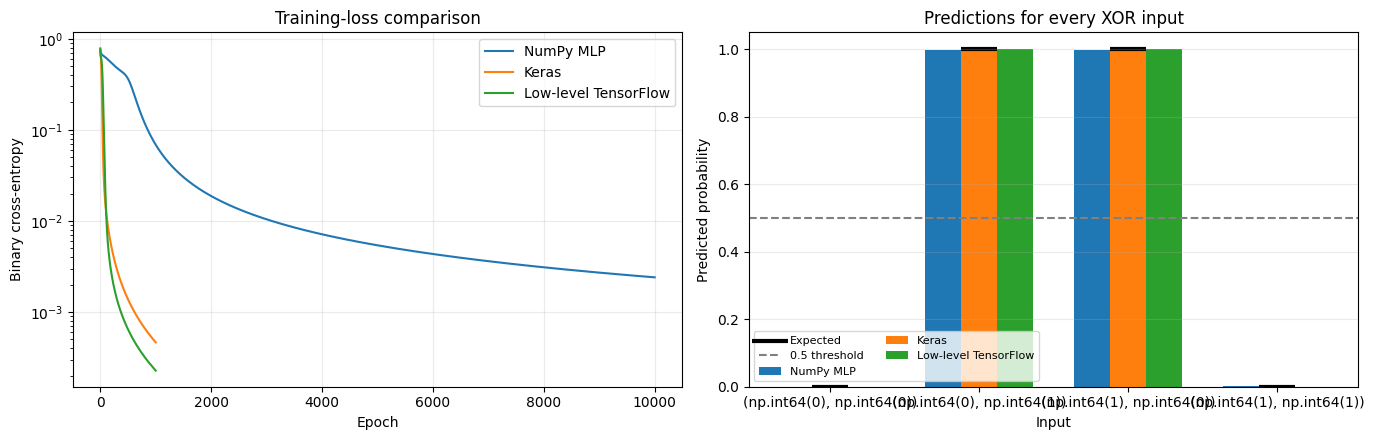

In [10]:
all_probabilities = {
    "NumPy MLP": numpy_prob.ravel(),
    "Keras": keras_prob.ravel(),
    "Low-level TensorFlow": tf_prob.ravel(),
}

comparison = xor_table.copy()
accuracy_rows = []
for name, probabilities in all_probabilities.items():
    predicted = (probabilities >= 0.5).astype(int)
    comparison[f"{name} probability"] = probabilities
    comparison[f"{name} class"] = predicted
    accuracy_rows.append([name, np.mean(predicted == y.ravel())])
display(comparison.round(4))
display(pd.DataFrame(accuracy_rows, columns=["Implementation", "Accuracy"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(numpy_loss, label="NumPy MLP")
axes[0].plot(keras_history.history["loss"], label="Keras")
axes[0].plot(tf_loss_history, label="Low-level TensorFlow")
axes[0].set(xlabel="Epoch", ylabel="Binary cross-entropy",
            title="Training-loss comparison", yscale="log")
axes[0].grid(alpha=0.25); axes[0].legend()

positions = np.arange(len(X))
width = 0.24
for j, (name, probabilities) in enumerate(all_probabilities.items()):
    axes[1].bar(positions + (j - 1) * width, probabilities, width, label=name)
axes[1].scatter(positions, y.ravel(), marker="_", s=700, color="black",
                linewidth=3, label="Expected")
axes[1].axhline(0.5, color="gray", ls="--", label="0.5 threshold")
axes[1].set(xticks=positions,
            xticklabels=[str(tuple(v.astype(int))) for v in X],
            xlabel="Input", ylabel="Predicted probability",
            title="Predictions for every XOR input", ylim=(0, 1.05))
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Additional exercise — decision boundaries

The background color shows each model's predicted class across the continuous 2-D input plane. Unlike a single perceptron, the MLP can create a bent or multi-part boundary that separates the two XOR diagonals.

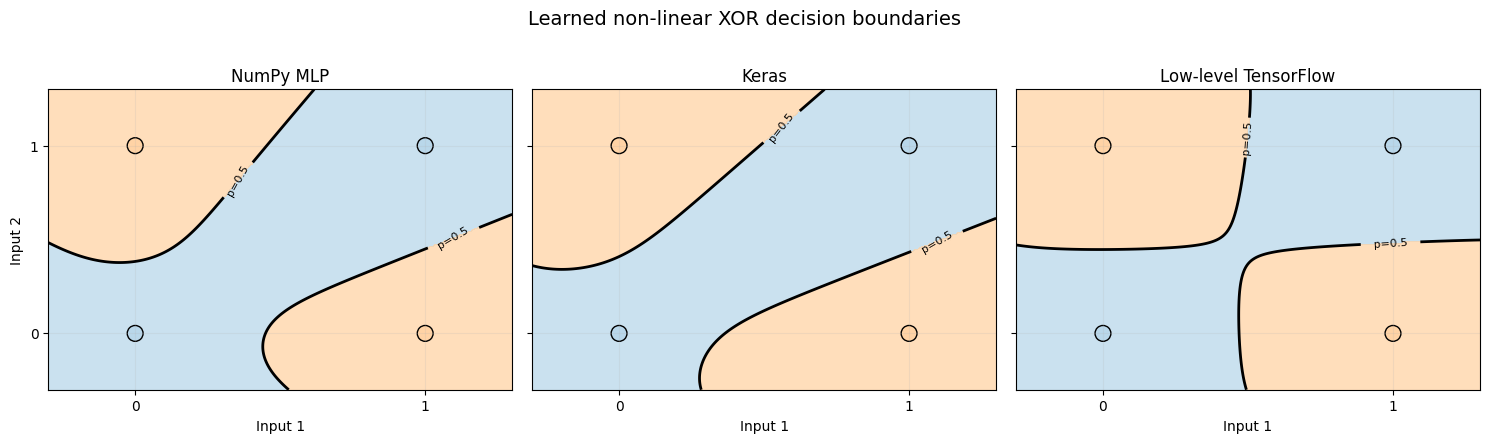

In [11]:
grid_x1, grid_x2 = np.meshgrid(np.linspace(-0.3, 1.3, 250),
                               np.linspace(-0.3, 1.3, 250))
grid = np.c_[grid_x1.ravel(), grid_x2.ravel()].astype(np.float32)

boundary_predictions = {
    "NumPy MLP": predict_numpy_mlp(grid, numpy_params).reshape(grid_x1.shape),
    "Keras": keras_model.predict(grid, verbose=0).reshape(grid_x1.shape),
    "Low-level TensorFlow": tf_forward(tf.constant(grid)).numpy().reshape(grid_x1.shape),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharex=True, sharey=True)
for ax, (name, surface) in zip(axes, boundary_predictions.items()):
    ax.contourf(grid_x1, grid_x2, surface >= 0.5, levels=[-0.5, 0.5, 1.5],
                cmap=CMAP, alpha=0.75)
    contour = ax.contour(grid_x1, grid_x2, surface, levels=[0.5],
                         colors="black", linewidths=2)
    ax.clabel(contour, fmt={0.5: "p=0.5"}, fontsize=8)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=CMAP,
               s=130, edgecolor="black")
    ax.set(title=name, xlabel="Input 1", xlim=(-0.3, 1.3), ylim=(-0.3, 1.3),
           xticks=[0, 1], yticks=[0, 1])
    ax.grid(alpha=0.18)
axes[0].set_ylabel("Input 2")
fig.suptitle("Learned non-linear XOR decision boundaries", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 9. Hyperparameter experiments

We change one factor at a time around a baseline Keras model:

- hidden neurons = 4
- activation = tanh
- learning rate = 0.05
- epochs = 1000

Because XOR has only four samples and neural-network training is stochastic, results can vary with initialization. A fixed seed makes this lab reproducible. For stronger conclusions, repeat every configuration with several seeds and report mean ± standard deviation.

In [ ]:
def run_keras_experiment(hidden_neurons=4, activation="tanh",
                         learning_rate=0.05, epochs=1000, seed=42):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(hidden_neurons, activation=activation),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="binary_crossentropy", metrics=["accuracy"])
    history = model.fit(X, y, epochs=epochs, verbose=0)
    probabilities = model.predict(X, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "Final loss": history.history["loss"][-1],
        "Accuracy": np.mean(predictions == y.ravel()),
        "History": history.history["loss"],
        "Predictions": probabilities,
    }

experiment_groups = {
    "Learning rate": [0.001, 0.01, 0.05, 0.1],
    "Activation": ["relu", "tanh", "sigmoid"],
    "Hidden neurons": [2, 4, 8, 16],
    "Epochs": [100, 500, 1000, 3000],
}

experiment_rows = []
for factor, values in experiment_groups.items():
    for value in values:
        kwargs = dict(hidden_neurons=4, activation="tanh",
                      learning_rate=0.05, epochs=1000)
        if factor == "Learning rate": kwargs["learning_rate"] = value
        elif factor == "Activation": kwargs["activation"] = value
        elif factor == "Hidden neurons": kwargs["hidden_neurons"] = value
        elif factor == "Epochs": kwargs["epochs"] = value
        result = run_keras_experiment(**kwargs)
        experiment_rows.append({
            "Factor": factor,
            "Value": str(value),
            "Final loss": result["Final loss"],
            "Accuracy": result["Accuracy"],
        })

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df.round(5))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (factor, _) in zip(axes.ravel(), experiment_groups.items()):
    subset = experiment_df[experiment_df["Factor"] == factor]
    bars = ax.bar(subset["Value"], subset["Accuracy"], color="#4C78A8", alpha=0.85)
    ax.set(title=f"Effect of {factor.lower()}", xlabel=factor, ylabel="Final accuracy",
           ylim=(0, 1.12))
    ax.axhline(1.0, color="#54A24B", ls="--", lw=1)
    for bar, loss in zip(bars, subset["Final loss"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025,
                f"loss={loss:.3f}", ha="center", va="bottom", fontsize=8, rotation=10)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("One-factor-at-a-time hyperparameter study", fontsize=15)
plt.tight_layout()
plt.show()

# A focused training-curve comparison for different learning rates.
fig, ax = plt.subplots(figsize=(9, 5))
for rate in experiment_groups["Learning rate"]:
    result = run_keras_experiment(learning_rate=rate, epochs=1000)
    ax.plot(result["History"], label=f"lr={rate}")
ax.set(xlabel="Epoch", ylabel="Binary cross-entropy",
       title="Learning rate changes convergence speed", yscale="log")
ax.grid(alpha=0.25); ax.legend()
plt.show()

## 10. Discussion of results

### Why does the MLP work when a perceptron fails?

A single perceptron produces one straight boundary. XOR is not linearly separable. Hidden neurons create several learned features/boundaries, and the sigmoid output combines them. This lets the complete network represent a non-linear decision region.

### Effect of learning rate

- A very small learning rate usually makes reliable but slow progress, so it may look under-trained at a fixed epoch count.
- A moderate learning rate commonly converges faster on this small problem.
- An excessively large rate can overshoot a good solution or make loss unstable. Adam often tolerates larger rates than plain SGD, but the principle remains.

### Effect of activation function

- **Tanh** is smooth, non-linear, and zero-centered; it is often effective for this tiny XOR network.
- **ReLU** can solve XOR, but a small network may occasionally get “dead” neurons depending on initialization and learning rate.
- **Sigmoid** hidden units can also solve XOR, but saturation can make gradients small and training slower. The output remains sigmoid because this is binary classification.

### Effect of hidden neurons/layers

- At least two suitable hidden neurons are theoretically sufficient for XOR.
- More neurons increase representational flexibility and can make optimization easier, but add parameters and are unnecessary for only four samples.
- A second hidden layer is allowed but not required for XOR; one non-linear hidden layer is enough.

### Effect of epochs

- Too few epochs may stop before the decision boundary is learned.
- More epochs generally reduce loss until convergence.
- Once every output is confidently correct, extra epochs improve confidence more than classification accuracy and may be computationally wasteful.

### Fairness of the comparison

Keras and the low-level TensorFlow implementation both use the TensorFlow engine, so this compares **levels of abstraction**, not unrelated numerical backends. Small numerical differences are expected because initialization and update details may differ. Final classification accuracy is more important than identical probabilities.

## 11. Conclusion

1. Manual perceptrons correctly implement the linearly separable AND, OR, and NOT gates.
2. A single perceptron fails on XOR because no straight line separates its two classes.
3. Adding a non-linear hidden layer allows an MLP to learn XOR.
4. The NumPy, Keras, and low-level TensorFlow MLPs are evaluated on all four combinations and should produce `[0, 1, 1, 0]` after successful training.
5. Learning rate controls update size, activation controls the available non-linearity and gradient behavior, neuron count controls capacity, and epochs control training duration.
6. Decision-boundary and loss plots make both the representational change and the training process visible.

